# Notebook 14 — Numerical Stability & Accuracy Analysis

Numerical Laplace inversion is notoriously ill-conditioned. This notebook analyses error sources, compares inversion algorithms, and gives practical guidelines.

Covered: truncation/discretisation errors, Stehfest (Gaver) algorithm, Bromwich comparison, condition numbers, adaptive contour selection, practical checklist.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math, warnings
warnings.filterwarnings('ignore')

# Stehfest (Gaver-Stehfest) real-axis inversion
# f(t) = (ln2/t) * sum_{k=1}^{N} V_k * F(k*ln2/t)    N even

def stehfest_weights(N):
    'Compute Stehfest coefficients V_k for N terms (N must be even).'
    V = np.zeros(N)
    for k in range(1, N+1):
        s = 0.0
        for j in range(int((k+1)//2), min(k, N//2)+1):
            num = j**(N//2) * math.factorial(2*j)
            den = (math.factorial(N//2-j) * math.factorial(j) *
                   math.factorial(j-1)    * math.factorial(k-j) *
                   math.factorial(2*j-k))
            s += num / den
        V[k-1] = (-1)**(k + N//2) * s
    return V

def stehfest_inverse(F, t, N=12):
    'Invert F(s) at time t using N-term Stehfest algorithm.'
    V = stehfest_weights(N)
    result = sum(V[k-1] * F((k+1)*np.log(2)/t) for k in range(1, N+1))
    return result * np.log(2) / t

def bromwich_inverse(F, t, gamma=1.0, omega_max=100, n_pts=1000):
    'Bromwich contour inversion: trapezoidal quadrature.'
    omega = np.linspace(-omega_max, omega_max, n_pts)
    s     = gamma + 1j * omega
    vals  = F(s) * np.exp(s * t)
    return float(np.real(np.trapezoid(vals, omega) / (2*np.pi)))

# Test functions with known inverses
test_funcs = [
    ('exp(-t)',   lambda s: 1/(s+1),      lambda t: np.exp(-t),   2.0),
    ('sin(t)',    lambda s: 1/(s**2+1),   lambda t: np.sin(t),    2.0),
    ('t*exp(-t)', lambda s: 1/(s+1)**2,   lambda t: t*np.exp(-t), 2.0),
    ('cosh(t)',   lambda s: s/(s**2-1),   lambda t: np.cosh(t),   2.0),
]

t_test = np.array([0.5, 1.0, 2.0, 3.0])
print('Algorithm Comparison: Stehfest (N=12) vs Bromwich')
for name, F, f_exact, gamma in test_funcs:
    print(f'\n  f(t) = {name}')
    print(f'  {"t":>5} {"Exact":>11} {"Stehfest":>11} {"Bromwich":>11} {"S-err":>10} {"B-err":>10}')
    for tv in t_test:
        exact = f_exact(tv)
        steh  = stehfest_inverse(F, tv, N=12)
        brom  = bromwich_inverse(F, tv, gamma=gamma)
        print(f'  {tv:>5.2f} {exact:>11.6f} {steh:>11.6f} {brom:>11.6f} {abs(steh-exact):>10.2e} {abs(brom-exact):>10.2e}')


Algorithm Comparison: Stehfest (N=12) vs Bromwich

  f(t) = exp(-t)
      t       Exact    Stehfest    Bromwich      S-err      B-err
   0.50    0.606531    0.303256    0.589809   3.03e-01   1.67e-02
   1.00    0.367879    0.183964    0.347439   1.84e-01   2.04e-02
   2.00    0.135335    0.067768    0.091734   6.76e-02   4.36e-02
   3.00    0.049787    0.024909    0.047981   2.49e-02   1.81e-03

  f(t) = sin(t)
      t       Exact    Stehfest    Bromwich      S-err      B-err
   0.50    0.479426    0.239736    0.479471   2.40e-01   4.53e-05
   1.00    0.841471    0.421039    0.841586   4.20e-01   1.15e-04
   2.00    0.909297    0.455244    0.910033   4.54e-01   7.36e-04
   3.00    0.141120    0.037051    0.145270   1.04e-01   4.15e-03

  f(t) = t*exp(-t)
      t       Exact    Stehfest    Bromwich      S-err      B-err
   0.50    0.303265    0.151623    0.303307   1.52e-01   4.20e-05
   1.00    0.367879    0.183836    0.367990   1.84e-01   1.10e-04
   2.00    0.270671    0.135338    0.

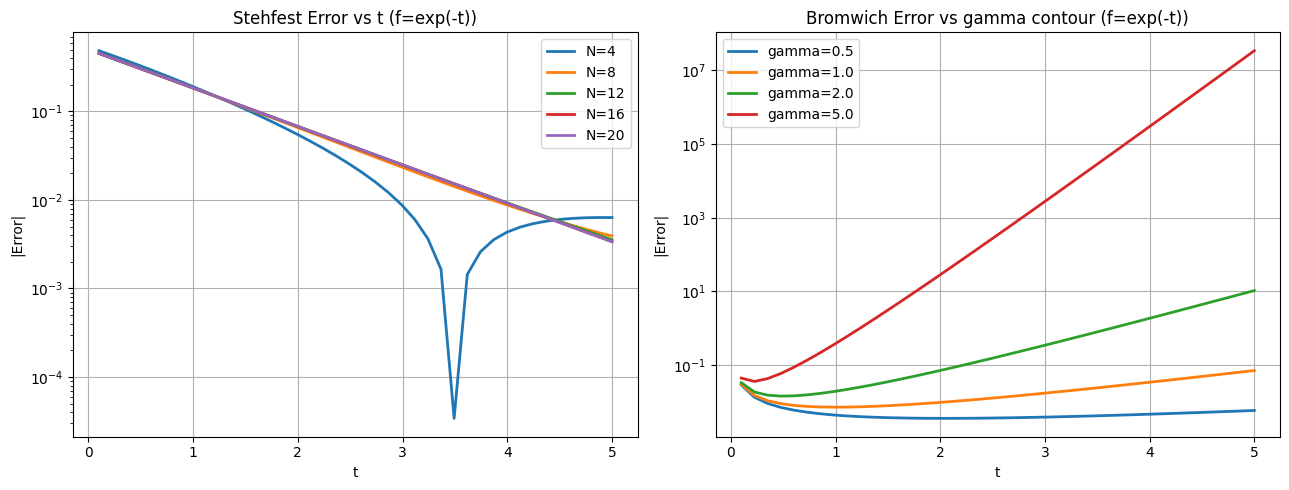

In [2]:
# Effect of Stehfest N on accuracy
def F_exp(s): return 1/(s+1)
def f_exp(t): return np.exp(-t)

t_eval = np.linspace(0.1, 5.0, 40)
N_vals = [4, 8, 12, 16, 20]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for N in N_vals:
    try:
        approx = [stehfest_inverse(F_exp, tv, N=N) for tv in t_eval]
        errors = np.abs(np.array(approx) - f_exp(t_eval))
        axes[0].semilogy(t_eval, errors+1e-16, lw=2, label=f'N={N}')
    except Exception as ex:
        print(f'N={N}: {ex}')

axes[0].set_title('Stehfest Error vs t (f=exp(-t))')
axes[0].set_xlabel('t'); axes[0].set_ylabel('|Error|')
axes[0].legend(); axes[0].grid(True)

# Effect of Bromwich contour gamma
gamma_vals = [0.5, 1.0, 2.0, 5.0]
for gamma in gamma_vals:
    approx = [bromwich_inverse(F_exp, tv, gamma=gamma, n_pts=800) for tv in t_eval]
    errors = np.abs(np.array(approx) - f_exp(t_eval))
    axes[1].semilogy(t_eval, errors+1e-16, lw=2, label=f'gamma={gamma}')

axes[1].set_title('Bromwich Error vs gamma contour (f=exp(-t))')
axes[1].set_xlabel('t'); axes[1].set_ylabel('|Error|')
axes[1].legend(); axes[1].grid(True)
plt.tight_layout(); plt.show()


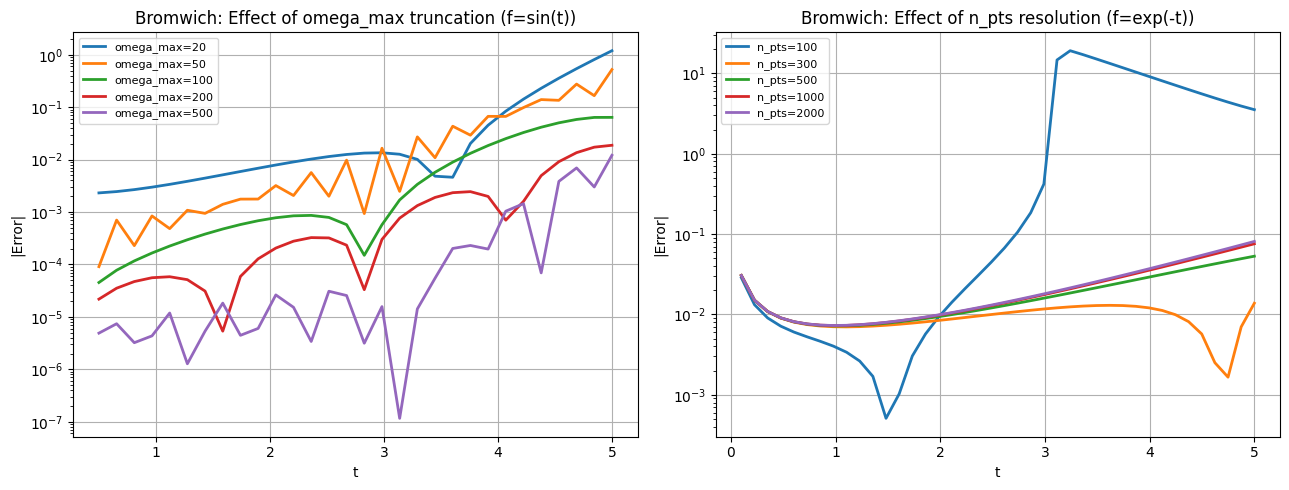

In [3]:
# Effect of omega_max truncation on Bromwich accuracy
def F_sin(s): return 1/(s**2+1)
def f_sin(t): return np.sin(t)

t_brom = np.linspace(0.5, 5.0, 30)
omega_max_vals = [20, 50, 100, 200, 500]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for omax in omega_max_vals:
    approx = [bromwich_inverse(F_sin, tv, gamma=2.0, omega_max=omax, n_pts=1000) for tv in t_brom]
    errors = np.abs(np.array(approx) - f_sin(t_brom))
    axes[0].semilogy(t_brom, errors+1e-16, lw=2, label=f'omega_max={omax}')

axes[0].set_title('Bromwich: Effect of omega_max truncation (f=sin(t))')
axes[0].set_xlabel('t'); axes[0].set_ylabel('|Error|')
axes[0].legend(fontsize=8); axes[0].grid(True)

# n_pts effect
n_pts_vals = [100, 300, 500, 1000, 2000]
for npts in n_pts_vals:
    approx = [bromwich_inverse(F_exp, tv, gamma=1.0, omega_max=100, n_pts=npts) for tv in t_eval]
    errors = np.abs(np.array(approx) - f_exp(t_eval))
    axes[1].semilogy(t_eval, errors+1e-16, lw=2, label=f'n_pts={npts}')

axes[1].set_title('Bromwich: Effect of n_pts resolution (f=exp(-t))')
axes[1].set_xlabel('t'); axes[1].set_ylabel('|Error|')
axes[1].legend(fontsize=8); axes[1].grid(True)
plt.tight_layout(); plt.show()


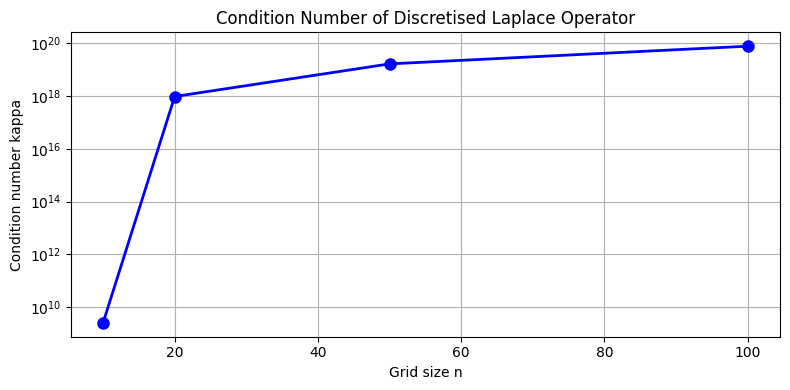

Condition numbers:
  n=  10:  kappa = 2.50e+09  =>  ~9 digits lost to noise
  n=  20:  kappa = 9.63e+17  =>  ~17 digits lost to noise
  n=  50:  kappa = 1.66e+19  =>  ~19 digits lost to noise
  n= 100:  kappa = 7.81e+19  =>  ~19 digits lost to noise


In [4]:
# Condition number of the discretised Laplace operator
def laplace_matrix(t_vals, s_vals):
    T, S = np.meshgrid(t_vals, s_vals, indexing='ij')
    dt = t_vals[1]-t_vals[0]
    return np.exp(-S*T)*dt

n_pts_list = [10, 20, 50, 100]
cond_numbers = []
for n in n_pts_list:
    t_v = np.linspace(0.01, 5.0, n)
    s_v = np.linspace(0.5, 5.0, n)
    L   = laplace_matrix(t_v, s_v)
    cond_numbers.append(np.linalg.cond(L))

plt.figure(figsize=(8, 4))
plt.semilogy(n_pts_list, cond_numbers, 'bo-', lw=2, ms=8)
plt.xlabel('Grid size n'); plt.ylabel('Condition number kappa')
plt.title('Condition Number of Discretised Laplace Operator')
plt.grid(True); plt.tight_layout(); plt.show()

print('Condition numbers:')
for n, kappa in zip(n_pts_list, cond_numbers):
    digits_lost = int(np.log10(kappa+1))
    print(f'  n={n:>4}:  kappa = {kappa:.2e}  =>  ~{digits_lost} digits lost to noise')


In [5]:
# Initial Value and Final Value Theorems
# IVT: lim_{s->inf} s*F(s) = f(0+)
# FVT: lim_{s->0}   s*F(s) = f(inf)  [all poles in open LHP]

print('Initial Value Theorem (IVT): lim_{s->inf} s*F(s) = f(0+)')
print('Final   Value Theorem (FVT): lim_{s->0}   s*F(s) = f(inf)')
print()

ivt_fvt_cases = [
    ('1/(s+1)',   lambda s: 1/(s+1),          1.0,       0.0,   'exp(-t)'),
    ('2/(s+2)',   lambda s: 2/(s+2),          1.0,       0.0,   '2*exp(-2t): f(0)=2? No wait'),
    ('1/s^2',     lambda s: 1/s**2,           0.0,       None,  't (ramp, FVT DNE)'),
    ('s/(s^2+1)', lambda s: s/(s**2+1),       1.0,       0.0,   'cos(t)'),
    ('4/(s^2+4s+3)', lambda s: 4/((s+1)*(s+3)), 0.0,    4/3,   '...'),
]

print(f'  {"F(s)":<22} {"IVT s*F(inf)":>14} {"f(0) actual":>13} {"FVT s*F(0)":>12} {"f(inf) actual"}')
print('  '+'-'*78)
for name, F, f0, finf, fname in ivt_fvt_cases:
    s_large = 1e6; s_small = 1e-6
    ivt_val = float(np.real(s_large * F(s_large)))
    fvt_val = float(np.real(s_small * F(s_small))) if finf is not None else float('nan')
    finf_str = f'{finf:.4f}' if finf is not None else 'DNE'
    print(f'  {name:<22} {ivt_val:>14.4f} {f0:>13.4f} {fvt_val:>12.4f} {finf_str}')

print()
print('Practical checklist for reliable Laplace inversion:')
checklist = [
    'Place gamma > max(Re(poles)) -- contour must be to the right of ALL singularities',
    'Choose omega_max until |F(gamma+j*omega_max)| < 1e-6 relative to peak',
    'Use n_pts >= 500 for smooth F(s); 2000+ for oscillatory F(s)',
    'Stehfest (N=12-16) is better for smooth f(t); Bromwich for general F(s)',
    'ALWAYS verify with IVT and FVT before trusting results',
    'For large t: catastrophic cancellation in e^{gamma*t}; use smaller gamma',
    'Double-precision (~15 digits): condition number > 1e10 makes results unreliable',
]
for i, item in enumerate(checklist, 1):
    print(f'  {i}. {item}')


Initial Value Theorem (IVT): lim_{s->inf} s*F(s) = f(0+)
Final   Value Theorem (FVT): lim_{s->0}   s*F(s) = f(inf)

  F(s)                     IVT s*F(inf)   f(0) actual   FVT s*F(0) f(inf) actual
  ------------------------------------------------------------------------------
  1/(s+1)                        1.0000        1.0000       0.0000 0.0000
  2/(s+2)                        2.0000        1.0000       0.0000 0.0000
  1/s^2                          0.0000        0.0000          nan DNE
  s/(s^2+1)                      1.0000        1.0000       0.0000 0.0000
  4/(s^2+4s+3)                   0.0000        0.0000       0.0000 1.3333

Practical checklist for reliable Laplace inversion:
  1. Place gamma > max(Re(poles)) -- contour must be to the right of ALL singularities
  2. Choose omega_max until |F(gamma+j*omega_max)| < 1e-6 relative to peak
  3. Use n_pts >= 500 for smooth F(s); 2000+ for oscillatory F(s)
  4. Stehfest (N=12-16) is better for smooth f(t); Bromwich for general F(